# Question 5: Excel/Python Analysis of South African GDP Growth and Employment

## Purpose of the Analysis

This analysis examines the relationship between South Africa's economic growth and employment across different economic sectors from 1961 to 2017.

The cleaned dataset contains South African GDP growth and employment data. Python is used to prepare, analyse and visualise the data in order to identify trends, patterns and relationships between GDP growth and employment.

The analysis focuses on:
- GDP growth over time
- Employment across economic sectors
- Employment trends over time
- The relationship between GDP growth and total employment
- Key findings from the combined datasets

## 1. Import libraries & load the cleaned dataset

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned South African dataset
file_path = "../../data/final_clean/GDP_Employment_South_Africa_Cleaned.csv"

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
    print("Shape:", df.shape)
except FileNotFoundError:
    print(f"Error: Could not find the file at '{file_path}'.")
    print("Please make sure the notebook is running from the repository root folder.")
    raise

df.head()

Dataset loaded successfully.
Shape: (570, 5)


,REF_AREA_LABEL,TIME_PERIOD,GDP_Growth,Employment_Thousands,Sector
0,South Africa,2017,1.157947,16536.302734,Sector: Total
1,South Africa,2017,1.157947,849.620773,Sector: Agriculture
2,South Africa,2017,1.157947,414.533398,Sector: Mining
3,South Africa,2017,1.157947,1855.818421,Sector: Manufacturing
4,South Africa,2017,1.157947,187.111598,Sector: Utilities


## 2.Verify the cleaned dataset


In [2]:
# Verify the cleaned dataset

print("===== DATASET VERIFICATION =====")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nCountries:")
print(df["REF_AREA_LABEL"].unique())

print("\nNumber of countries:")
print(df["REF_AREA_LABEL"].nunique())

print("\nYears:")
print(df["TIME_PERIOD"].min(), "to", df["TIME_PERIOD"].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nSectors:")
print(df["Sector"].unique())

===== DATASET VERIFICATION =====

Shape:
(570, 5)

Columns:
['REF_AREA_LABEL', 'TIME_PERIOD', 'GDP_Growth', 'Employment_Thousands', 'Sector']

Countries:
['South Africa']

Number of countries:
1

Years:
1961 to 2017

Missing values:
REF_AREA_LABEL          0
TIME_PERIOD             0
GDP_Growth              0
Employment_Thousands    0
Sector                  0
dtype: int64

Duplicate rows:
0

Sectors:
['Sector: Total' 'Sector: Agriculture' 'Sector: Mining'
 'Sector: Manufacturing' 'Sector: Utilities' 'Sector: Construction'
 'Sector: Trade services' 'Sector: Transport services'
 'Sector: Finance and business services' 'Sector: Other services']


## 3. Prepare the data for analysis
### 3.1 Clean the sector names

In [3]:
# Clean the sector names for easier analysis and presentation

df["Sector_Name"] = df["Sector"].str.replace("Sector: ", "", regex=False)

print("===== CLEANED SECTOR NAMES =====")
print(df[["Sector", "Sector_Name"]].drop_duplicates().to_string(index=False))


===== CLEANED SECTOR NAMES =====
                               Sector                   Sector_Name
                        Sector: Total                         Total
                  Sector: Agriculture                   Agriculture
                       Sector: Mining                        Mining
                Sector: Manufacturing                 Manufacturing
                    Sector: Utilities                     Utilities
                 Sector: Construction                  Construction
               Sector: Trade services                Trade services
           Sector: Transport services            Transport services
Sector: Finance and business services Finance and business services
               Sector: Other services                Other services


### 3.2 Yearly GDP data




In [4]:
# Create a yearly GDP dataset

gdp_by_year = (
    df[["TIME_PERIOD", "GDP_Growth"]]
    .drop_duplicates()
    .sort_values("TIME_PERIOD")
    .reset_index(drop=True)
)

print("===== YEARLY GDP DATA =====")
print("Number of yearly GDP observations:", len(gdp_by_year))
print("First year:", gdp_by_year["TIME_PERIOD"].min())
print("Last year:", gdp_by_year["TIME_PERIOD"].max())

gdp_by_year.head()

===== YEARLY GDP DATA =====
Number of yearly GDP observations: 57
First year: 1961
Last year: 2017


,TIME_PERIOD,GDP_Growth
0,1961,3.844734
1,1962,6.177931
2,1963,7.373709
3,1964,7.939609
4,1965,6.122798


### 3.3 Yearly total employment data


In [5]:
# Create a yearly total employment dataset

employment_by_year = (
    df[df["Sector_Name"] == "Total"]
    [["TIME_PERIOD", "Employment_Thousands"]]
    .sort_values("TIME_PERIOD")
    .reset_index(drop=True)
)

print("===== YEARLY TOTAL EMPLOYMENT DATA =====")
print("Number of yearly employment observations:", len(employment_by_year))
print("First year:", employment_by_year["TIME_PERIOD"].min())
print("Last year:", employment_by_year["TIME_PERIOD"].max())

employment_by_year.head()

===== YEARLY TOTAL EMPLOYMENT DATA =====
Number of yearly employment observations: 57
First year: 1961
Last year: 2017


,TIME_PERIOD,Employment_Thousands
0,1961,4653.677246
1,1962,4716.896973
2,1963,4795.137207
3,1964,4930.197754
4,1965,5064.761230


## 4. Analyse GDP Growth
### 4.1 GDP growth statistics

In [6]:
# Analyse GDP growth over time

print("===== GDP GROWTH ANALYSIS =====")

print("\nNumber of yearly GDP observations:", len(gdp_by_year))

print("\nAverage GDP growth:")
print(round(gdp_by_year["GDP_Growth"].mean(), 2), "%")

print("\nHighest GDP growth:")
highest_gdp = gdp_by_year.loc[gdp_by_year["GDP_Growth"].idxmax()]
print("Year:", int(highest_gdp["TIME_PERIOD"]))
print("GDP growth:", round(highest_gdp["GDP_Growth"], 2), "%")

print("\nLowest GDP growth:")
lowest_gdp = gdp_by_year.loc[gdp_by_year["GDP_Growth"].idxmin()]
print("Year:", int(lowest_gdp["TIME_PERIOD"]))
print("GDP growth:", round(lowest_gdp["GDP_Growth"], 2), "%")

print("\nGDP growth summary:")
print(gdp_by_year["GDP_Growth"].describe())

===== GDP GROWTH ANALYSIS =====

Number of yearly GDP observations: 57

Average GDP growth:
3.02 %

Highest GDP growth:
Year: 1964
GDP growth: 7.94 %

Lowest GDP growth:
Year: 1992
GDP growth: -2.14 %

GDP growth summary:
count    57.000000
mean      3.023583
std       2.431271
min      -2.137033
25%       1.413826
50%       3.100000
75%       4.571945
max       7.939609
Name: GDP_Growth, dtype: float64


##  5. GDP Growth Over Time Chart

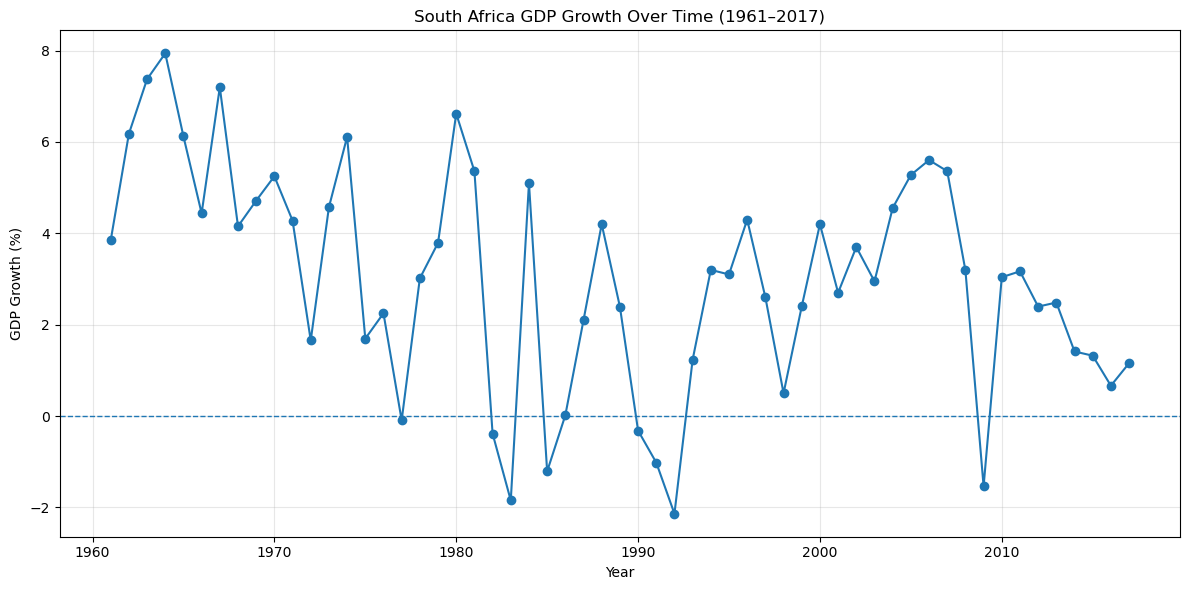

In [7]:
# Chart 1: GDP Growth Over Time

plt.figure(figsize=(12, 6))

plt.plot(
    gdp_by_year["TIME_PERIOD"],
    gdp_by_year["GDP_Growth"],
    marker="o",
    linewidth=1.5
)

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.title("South Africa GDP Growth Over Time (1961–2017)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


### GDP Growth
*The line chart shows South Africa's GDP growth rate fluctuating dramatically between approximately -2% and 8% from 1961 to 2017. The line moves up and down continuously, indicating high volatility throughout the entire period. The 1960s begin with relatively high growth rates around 6–8%, followed by sharp drops and recoveries in the 1
970s and 1980s. From the mid-1990s, the line shows a brief upward spike followed by more moderate growth around 4% until 2007. The most notable feature is the steep downward plunge in 2008–2009, where the line drops sharply below zero. After a recovery, the line trends generally downward throughout the 2010s, hovering around 0–3%, with a slight dip into negative territory near the end. The overall pattern shows no sustained period of stable growth, with the line constantly rising and falling across the decades.

## 6.Analyse Employment by Economic Sector.
### 6.1  Calculate average employment by sector

In [8]:
# Analyse average employment by economic sector

sector_employment = (
    df[df["Sector_Name"] != "Total"]
    .groupby("Sector_Name")["Employment_Thousands"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sector_employment.columns = [
    "Sector",
    "Average_Employment_Thousands"
]

print("===== AVERAGE EMPLOYMENT BY SECTOR =====")
print(sector_employment.to_string(index=False))

===== AVERAGE EMPLOYMENT BY SECTOR =====
                       Sector  Average_Employment_Thousands
               Other services                   2232.169429
               Trade services                   2071.336669
                Manufacturing                   1473.759850
                  Agriculture                   1039.694930
Finance and business services                    831.599820
                 Construction                    642.529747
           Transport services                    515.611710
                       Mining                    473.721739
                    Utilities                     72.421918


### 6.2 Employment by Economic Sector Chart


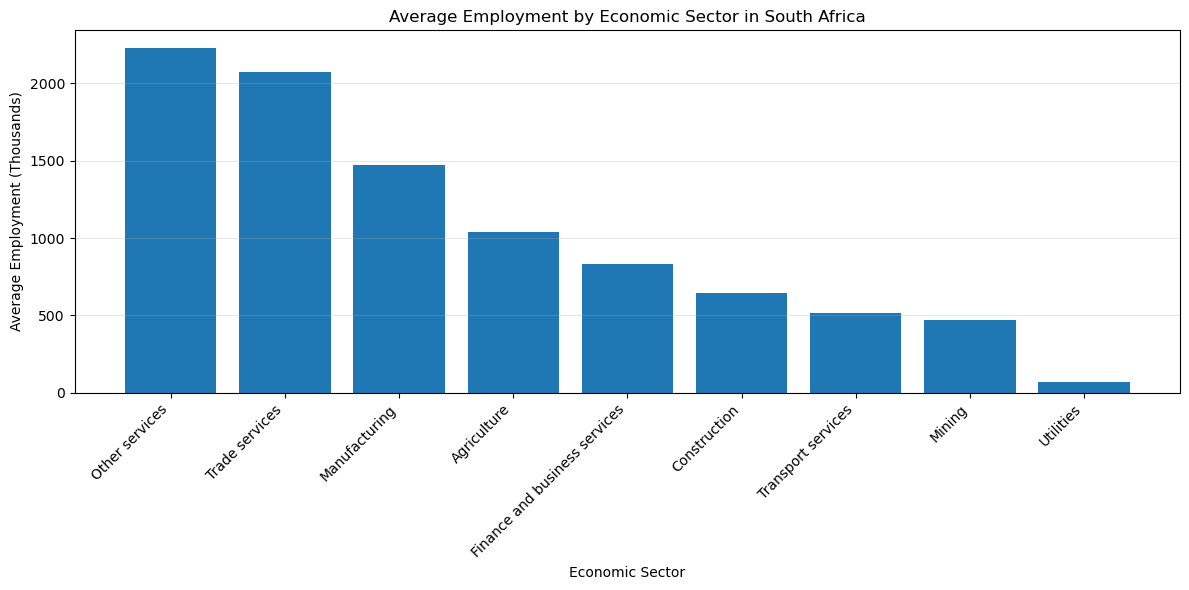

In [9]:
# Chart 2: Average Employment by Economic Sector

plt.figure(figsize=(12, 6))

plt.bar(
    sector_employment["Sector"],
    sector_employment["Average_Employment_Thousands"]
)

plt.title("Average Employment by Economic Sector in South Africa")
plt.xlabel("Economic Sector")
plt.ylabel("Average Employment (Thousands)")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Employment by Economic Sector
*The bar chart displays the average employment levels across nine economic sectors in South Africa, measured in thousands. Trade services stands out as the largest employer with average employment exceeding approximately 2,000 (in thousands), followed by Other services at around 1,800, and Manufacturing at roughly 1,500. Agriculture and Finance and business services show moderate averages, each around 1,200–1,400, while Construction and Transport services have lower averages, approximately 800–1,000. Mining has a notably smaller bar at around 400–500, and Utilities has the smallest average employment of all sectors, barely registering above 100. The clear dominance of Trade services and Other services confirms that the South African economy is heavily service-oriented, with these two sectors consistently employing the most people on average over time. The moderate position of Manufacturing indicates a degree of industrial activity, though it remains below the leading service sectors. The very low bars for Mining and Utilities reflect their capital-intensive nature and limited labour absorption relative to services. The relatively low average for Agriculture underscores its declining importance in employment over the decades, consistent with the broader economic shift away from primary industries. Overall, the chart illustrates a labour market strongly tilted toward services, with trade and other services dominating, while primary and extractive industries play a much smaller role in average employment.

## 7. Analyse Total Employment Over Time.
### 7.1 Analyse employment over time

In [10]:
# Analyse total employment over time

print("===== TOTAL EMPLOYMENT OVER TIME =====")

print("Number of yearly employment observations:", len(employment_by_year))
print("First year:", employment_by_year["TIME_PERIOD"].min())
print("Last year:", employment_by_year["TIME_PERIOD"].max())

print("\nEmployment summary statistics:")
print(employment_by_year["Employment_Thousands"].describe())

print("\nFirst 5 years:")
print(employment_by_year.head().to_string(index=False))

print("\nLast 5 years:")
print(employment_by_year.tail().to_string(index=False))

===== TOTAL EMPLOYMENT OVER TIME =====
Number of yearly employment observations: 57
First year: 1961
Last year: 2017

Employment summary statistics:
count       57.000000
mean      9352.845823
std       3736.307765
min       4653.677246
25%       5972.548340
50%       8615.634766
75%      12022.030273
max      16536.302734
Name: Employment_Thousands, dtype: float64

First 5 years:
 TIME_PERIOD  Employment_Thousands
        1961           4653.677246
        1962           4716.896973
        1963           4795.137207
        1964           4930.197754
        1965           5064.761230

Last 5 years:
 TIME_PERIOD  Employment_Thousands
        2013          15159.450195
        2014          15415.942383
        2015          16130.101562
        2016          16188.352539
        2017          16536.302734


### 7.2 Total Employment Over Time.

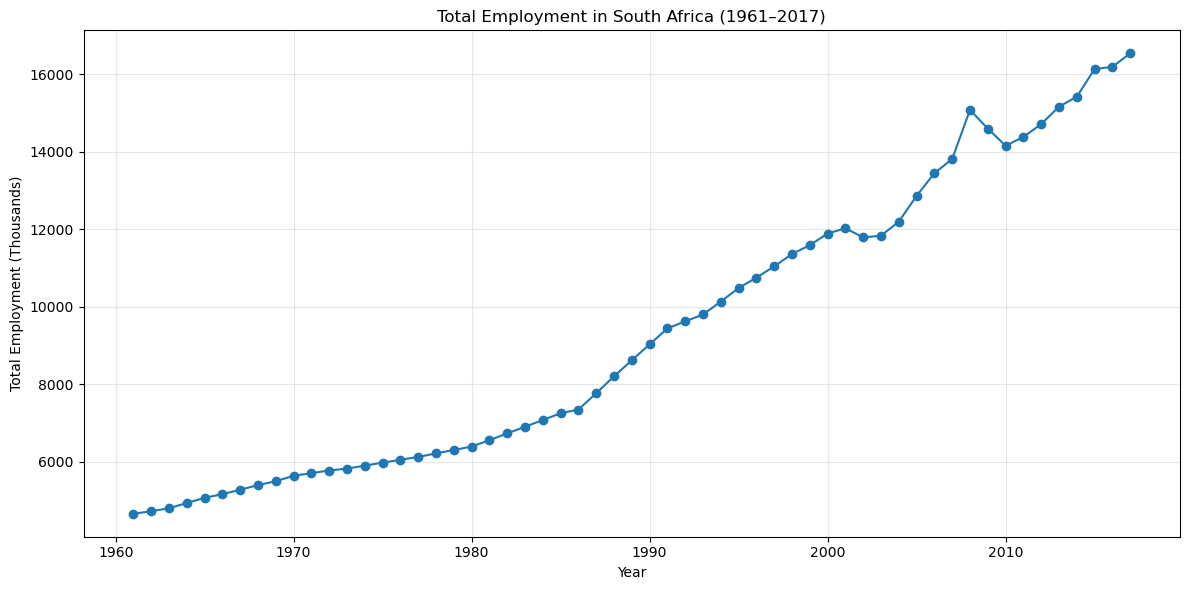

In [11]:
# Chart 3: Total Employment Over Time

plt.figure(figsize=(12, 6))

plt.plot(
    employment_by_year["TIME_PERIOD"],
    employment_by_year["Employment_Thousands"],
    marker="o",
    linewidth=1.5
)

plt.title("Total Employment in South Africa (1961–2017)")
plt.xlabel("Year")
plt.ylabel("Total Employment (Thousands)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Employment Over Time
The line chart displays total employment in South Africa from 1961 to 2017, measured in thousands. The line shows a clear and consistent upward trend over the entire period, starting at approximately 6,000 (6 million) in 1961 and rising steadily to around 18,000–24,000 (18-24 million) by 2017. The growth appears relatively steady and linear, with the line moving upward without major dips or sharp fluctuations, suggesting a consistent expansion of the labour force over the five decades. There are no significant plateaus or declines visible, indicating that employment grew persistently year after year, likely driven by population growth, economic expansion, and structural changes in the economy. The slope of the line appears to steepen slightly in the later years, particularly from the 1990s onward, suggesting an accelerated pace of job creation during the post-apartheid era. The overall pattern reflects a labour market that expanded considerably over time, though the chart does not indicate whether this growth kept pace with population growth or whether it translated into improved employment rates. The steady upward trajectory highlights South Africa's growing workforce, but without additional context, it remains unclear whether this growth was sufficient to absorb the increasing number of job seekers entering the labour market each year..

## 8. GDP Growth and Employment Together
### 8.1 Combine the two analyses

In [12]:
# Combine GDP growth and total employment by year

gdp_employment = pd.merge(
    gdp_by_year,
    employment_by_year,
    on="TIME_PERIOD",
    how="inner"
)

print("===== GDP GROWTH AND EMPLOYMENT =====")
print("Number of observations:", len(gdp_employment))

print("\nFirst 5 observations:")
print(gdp_employment.head().to_string(index=False))

print("\nLast 5 observations:")
print(gdp_employment.tail().to_string(index=False))

===== GDP GROWTH AND EMPLOYMENT =====
Number of observations: 57

First 5 observations:
 TIME_PERIOD  GDP_Growth  Employment_Thousands
        1961    3.844734           4653.677246
        1962    6.177931           4716.896973
        1963    7.373709           4795.137207
        1964    7.939609           4930.197754
        1965    6.122798           5064.761230

Last 5 observations:
 TIME_PERIOD  GDP_Growth  Employment_Thousands
        2013    2.485468          15159.450195
        2014    1.413826          15415.942383
        2015    1.321862          16130.101562
        2016    0.664552          16188.352539
        2017    1.157947          16536.302734


### 8.2 Calculate the correlation between GDP growth and total employment.

In [13]:
# Calculate the correlation between GDP growth and total employment

correlation = gdp_employment[
    ["GDP_Growth", "Employment_Thousands"]
].corr().loc["GDP_Growth", "Employment_Thousands"]


print("===== GDP GROWTH AND EMPLOYMENT CORRELATION =====")
print("Correlation:", round(correlation, 4))


===== GDP GROWTH AND EMPLOYMENT CORRELATION =====
Correlation: -0.2975


### 8.3 Visualise the relationship between GDP Growth and Employment.

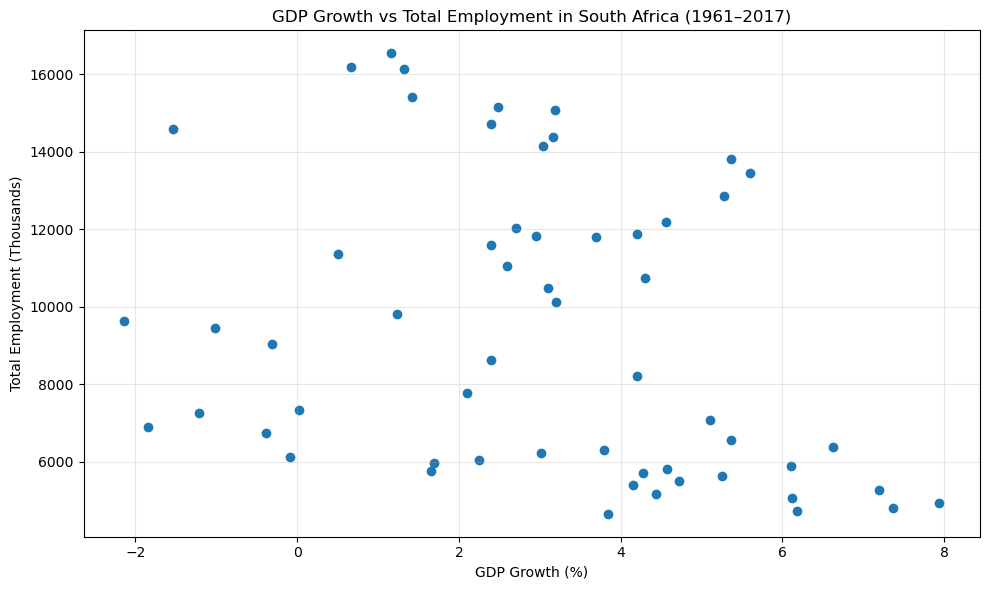

In [14]:
# Chart 4: GDP Growth vs Total Employment

plt.figure(figsize=(10, 6))

plt.scatter(
    gdp_employment["GDP_Growth"],
    gdp_employment["Employment_Thousands"]
)

plt.title("GDP Growth vs Total Employment in South Africa (1961–2017)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Total Employment (Thousands)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Relationship Between GDP Growth and Employment

*The scatter plot displays the relationship between GDP growth rate (X-axis) and total employment in thousands (Y-axis) for South Africa. The data points show employment ranging from approximately 5,000 to 17,500 (in thousands) across GDP growth rates spanning from around -2% to 8%. The points are widely dispersed across the chart without forming a clear upward or downward pattern, suggesting a weak or non-existent correlation between GDP growth and employment levels. There is a noticeable cluster of points at higher employment levels (above 15,000) that appear across a broad range of growth rates, from negative to positive, indicating that high employment persisted even during periods of low or negative economic growth. Conversely, lower employment levels (below 10,000) are also scattered across various growth rates, showing that low employment occurred during both economic expansions and contractions. This lack of a clear relationship suggests that employment does not move in tandem with GDP growth, and other factors such as population growth, labour market policies, structural changes, and informal sector activity likely play more significant roles in determining employment outcomes. The wide scatter indicates that GDP growth alone is not a reliable predictor of employment levels in South Africa, reflecting the complex and multifaceted nature of the country's labour market dynamics

### 9. Conditional Formatting

In [15]:
# Conditional formatting: Average Employment by Sector

formatted_sector_employment = (
    sector_employment.style
    .background_gradient(
        subset=["Average_Employment_Thousands"],
        cmap="YlGn"
    )
    .format({
        "Average_Employment_Thousands": "{:,.2f}"
    })
)

formatted_sector_employment

,Sector,Average_Employment_Thousands
0,Other services,"2,232.17"
1,Trade services,"2,071.34"
2,Manufacturing,"1,473.76"
3,Agriculture,"1,039.69"
4,Finance and business services,831.60
5,Construction,642.53
6,Transport services,515.61
7,Mining,473.72
8,Utilities,72.42


## Conclusion

The analysis of South African GDP growth and employment from 1961 to 2017 shows that GDP growth fluctuated considerably over the period, while total employment increased substantially over the long term. The average GDP growth was approximately 3.02%.

Employment was concentrated mainly in Other services, Trade services, Manufacturing, and Agriculture, while Utilities had the lowest average employment.

The correlation between annual GDP growth and total employment was -0.2975, indicating a weak negative linear relationship. This suggests that annual GDP growth and employment did not move together in a simple or consistent pattern during the period analysed.

Overall, the findings show that higher annual GDP growth did not automatically result in higher employment in the same period. Employment trends can be influenced by other economic and structural factors, meaning that GDP growth and employment should not be assumed to have a direct one-to-one relationship.